## Get data from Drive

In [1]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings



warnings.filterwarnings('ignore')

## Data Loading

In [3]:
# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [4]:

# --- 5. MAIN EXECUTION ---

spp_filepath = r'/gdrive/MyDrive/Graduation Data/6_EW_EVENING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/6_EW_Evening_K.csv'
    # 1) step is to return merged data
unified_df1, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df1)

✓ SPP file loaded with 15734 rows.
✓ Kinematic file loaded with 12252 rows.


12252

In [5]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/6_EW_MORNING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/6_EW_Morning_K.csv'
    # 1) step is to return merged data
unified_df2, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df2)

✓ SPP file loaded with 15291 rows.
✓ Kinematic file loaded with 15060 rows.


15060

In [6]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/6_NS_EVENING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/6_NS_Evening_K.csv'
    # 1) step is to return merged data
unified_df3, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df3)

✓ SPP file loaded with 14870 rows.
✓ Kinematic file loaded with 11375 rows.


11374

In [7]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/6_NS_MORNING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/6_NS_Morning_K.csv'
    # 1) step is to return merged data
unified_df4, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df4)

✓ SPP file loaded with 15070 rows.
✓ Kinematic file loaded with 13307 rows.


13307

In [8]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/7_EW_EVENING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/7_EW_Evening_K.csv'
    # 1) step is to return merged data
unified_df5, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df5)

✓ SPP file loaded with 15645 rows.
✓ Kinematic file loaded with 15286 rows.


15286

In [9]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/7_EW_MORNING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/7_EW_Morning_K.csv'
    # 1) step is to return merged data
unified_df6, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df6)

✓ SPP file loaded with 15543 rows.
✓ Kinematic file loaded with 15075 rows.


15075

In [10]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/7_NS_EVENING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/7_NS_Evening_K.csv'
    # 1) step is to return merged data
unified_df7, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df7)

✓ SPP file loaded with 15655 rows.
✓ Kinematic file loaded with 13947 rows.


13946

In [11]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/7_NS_MORNING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/7_NS_Morning_K.csv'
    # 1) step is to return merged data
unified_df8, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df8)

✓ SPP file loaded with 15642 rows.
✓ Kinematic file loaded with 14279 rows.


14279

In [12]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/10_EW_MORNING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/10_EW_Morning_K.csv'
    # 1) step is to return merged data
unified_df9, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df9)

✓ SPP file loaded with 15675 rows.
✓ Kinematic file loaded with 15512 rows.


15512

In [13]:
spp_filepath = r'/gdrive/MyDrive/Graduation Data/10_NS_MORNING_S.csv'
kinematic_filepath = r'/gdrive/MyDrive/Graduation Data/10_NS_Morning_K.csv'
    # 1) step is to return merged data
unified_df10, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df10)

✓ SPP file loaded with 15027 rows.
✓ Kinematic file loaded with 13541 rows.


13541

## Concatinating data into Single DataFrame

In [14]:
# ignore_index=True  --> means Pandas will discard the original row indices and create a new continuous index for the combined DataFrame.
unified_df = pd.concat([unified_df1, unified_df2, unified_df3,unified_df4, unified_df5, unified_df6, unified_df7, unified_df8, unified_df9, unified_df10], ignore_index=True)

# Sort by GPST
unified_df = unified_df.sort_values('GPST').reset_index(drop=True)
unified_df = unified_df.drop(columns=["Unnamed: 0"])
print(f"Total number of rows after appending: {len(unified_df)}")
print("\nFirst few rows to verify sorting:")
unified_df.head()

Total number of rows after appending: 139632

First few rows to verify sorting:


,GPST,avg_snr,min_snr,max_residual,x_x,y_x,z_x,ns,sdx(m),sdy(m),sdz(m),sdxy(m),sdyz(m),sdzx(m),x_y,y_y,z_y,diff_x,diff_y,diff_z
0,2023-12-06 01:59:08,31.750000,26.0,1.6368,459252.2586,5.634018e+06,2.947007e+06,8.0,52.2081,36.9664,49.3526,40.7052,-37.1917,-50.0592,459291.9968,5.634082e+06,2.946966e+06,39.7382,64.6765,-40.9517
1,2023-12-06 01:59:09,31.625000,25.0,1.7018,459252.7407,5.634016e+06,2.947006e+06,8.0,52.2223,36.9710,49.3521,40.7137,-37.1948,-50.0660,459289.5836,5.634087e+06,2.946966e+06,36.8429,71.1549,-39.4826
2,2023-12-06 01:59:49,29.000000,23.0,5.5528,459308.8238,5.634051e+06,2.946946e+06,11.0,10.2943,17.0425,16.1441,3.2766,10.4717,-11.0646,459295.8737,5.634077e+06,2.946962e+06,-12.9501,26.0052,16.4584
3,2023-12-06 02:06:09,27.500000,19.0,11.0868,459293.8285,5.634046e+06,2.946964e+06,16.0,4.6884,16.7968,9.3480,-2.4012,11.4236,-3.5037,459293.3256,5.634080e+06,2.946963e+06,-0.5029,34.6117,-0.4802
4,2023-12-06 02:06:25,27.666667,16.0,11.5613,459294.7681,5.634057e+06,2.946969e+06,15.0,4.6947,17.2442,9.9720,-2.3391,12.0011,-3.4614,459285.2562,5.634097e+06,2.946964e+06,-9.5119,39.3426,-5.2728


In [32]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt


def train_ensemble_and_evaluate(unified_df, feature_cols):
    # --- Data prep ---
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)


    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    # --- Train model ---
    rf.fit(X_train_scaled, y_train_scaled)

    # --- Make predictions ---
    y_pred_scaled = rf.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_vals = y_test.to_numpy()

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: RANDOM FOREST\n" + "="*80)
    per_axis_rmse = []

    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(
            f"--- Axis {axis} ---\n"
            f"  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n"
            f"  RMSE (m): {rmse:.4f}\n"
        )

    print(f"Overall mean RMSE (m): {np.mean(per_axis_rmse):.4f}")

    # --- Feature importance ---
    plt.figure(figsize=(10, 6))
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.title("Random Forest Feature Importance", fontsize=18)
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)),
               [feature_cols[i] for i in indices],
               rotation=45)
    plt.tight_layout()
    plt.show()

    return rf, x_scaler, y_scaler, X_test, y_pred


In [33]:
# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error from diff_x, diff_y, diff_z
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error = x_x + correction using AI
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    # overall error for improvement_distnace = testing_kinematic -  Corrected 3D Error
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

In [34]:
unified_df[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,88376.000000,88376.000000,88376.000000
mean,-0.980431,-8.646857,-7.921765
std,1.812704,5.364135,3.125649
min,-5.947300,-22.529100,-16.460200
25%,-2.282400,-12.298050,-9.777800
50%,-0.929600,-8.481150,-7.522950
75%,0.318700,-4.966350,-5.643875
max,3.680600,5.722100,-1.218100


## Creating Anomaly Detection Model

In [35]:
from sklearn.ensemble import IsolationForest

# Ensure diff columns exist
cols = ['diff_x', 'diff_y', 'diff_z']
missing = [c for c in cols if c not in unified_df.columns]
if missing:
    raise KeyError(f'Missing required diff columns in unified_df: {missing}')

# Handle NaNs directly in unified_df (fill with median)
unified_df[cols] = unified_df[cols].fillna(unified_df[cols].median())

# Train IsolationForest on the diff columns
iso = IsolationForest(
    n_estimators=500,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(unified_df[cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
unified_df['anomaly'] = iso.predict(unified_df[cols])

# Print summary
print('Anomaly value counts (1 = normal, -1 = anomaly):')
print(unified_df['anomaly'].value_counts())


Anomaly value counts (1 = normal, -1 = anomaly):
anomaly
 1    60125
-1    28251
Name: count, dtype: int64


In [36]:
"""anomly_df = unified_df[['GPST','avg_snr','min_snr','max_residual','x_x','y_x','z_x','ns','sdx(m)','sdy(m)','sdz(m)','sdxy(m)','sdyz(m)','sdzx(m)','anomaly']]
anomly_df.to_csv("data_after_outlier_detection1.csv", index=True)"""

'anomly_df = unified_df[[\'GPST\',\'avg_snr\',\'min_snr\',\'max_residual\',\'x_x\',\'y_x\',\'z_x\',\'ns\',\'sdx(m)\',\'sdy(m)\',\'sdz(m)\',\'sdxy(m)\',\'sdyz(m)\',\'sdzx(m)\',\'anomaly\']]\nanomly_df.to_csv("data_after_outlier_detection1.csv", index=True)'

In [37]:
unified_df = unified_df[unified_df['anomaly'] == 1].drop(columns=['anomaly'])
print(f"Data size before cleaning: {len(unified_df)}")

Data size before cleaning: 60125


In [38]:
unified_df[['diff_x', 'diff_y', 'diff_z']].describe()

,diff_x,diff_y,diff_z
count,60125.00000,60125.000000,60125.000000
mean,-0.89008,-8.832686,-7.280568
std,1.46928,4.011200,2.372902
min,-4.65400,-18.840400,-14.585700
25%,-2.02020,-11.862600,-8.587900
50%,-0.86270,-8.677100,-6.976000
75%,0.19810,-5.758600,-5.556100
max,2.63190,1.085300,-2.576900


## Code to test with (Using RMSE)

In [42]:
def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):


    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # --- ORIGINAL 3D ERROR (SPP vs RTK) ---
    original_3d_errors = np.sqrt(
        test_df['diff_x']**2 +
        test_df['diff_y']**2 +
        test_df['diff_z']**2
    )

    rmse_original_3d = np.sqrt(np.mean(original_3d_errors**2))

    # --- APPLY ML CORRECTION ---
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    # --- Compute corrected residuals vs RTK ---
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(
        corrected_diff_x**2 +
        corrected_diff_y**2 +
        corrected_diff_z**2
    )

    rmse_corrected_3d = np.sqrt(np.mean(corrected_3d_errors**2))

    # --- Improvement ---
    improvement = rmse_original_3d - rmse_corrected_3d
    improvement_percent = (
        (improvement / rmse_original_3d) * 100
        if rmse_original_3d != 0 else 0
    )

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"3D RMSE (Original):  {rmse_original_3d:.4f} m")
    print(f"3D RMSE (Corrected): {rmse_corrected_3d:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

    return rmse_original_3d, rmse_corrected_3d


## **Scenario 1**


FINAL EVALUATION: RANDOM FOREST
--- Axis X ---
  R² Score: 0.5756
  RMSE (m): 0.9623

--- Axis Y ---
  R² Score: 0.6695
  RMSE (m): 2.3267

--- Axis Z ---
  R² Score: 0.7108
  RMSE (m): 1.2698

Overall mean RMSE (m): 1.5196


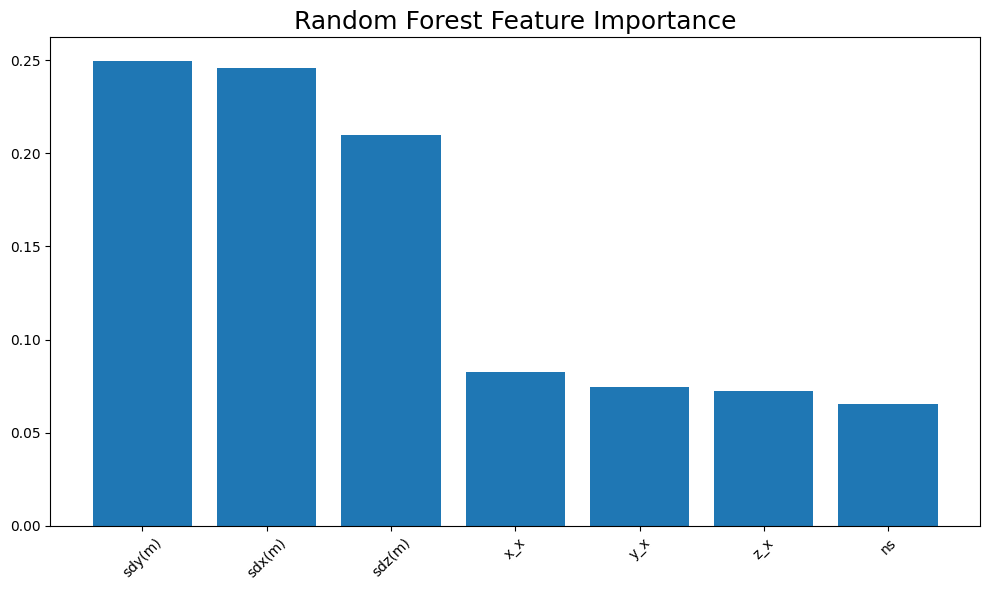


MODEL ACCURACY IMPROVEMENT ANALYSIS
3D RMSE (Original):  12.4667 m
3D RMSE (Corrected): 2.8199 m

Improvement: 9.6469 m (77.38%)

✓ Model, scaler, and feature list saved successfully!

✓ Analysis complete!


In [43]:
# 2) Train Random Forest


model, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(
    unified_df, feature_cols
)

# Get matching test dataframe
test_df = unified_df.loc[X_test.index]

# Evaluate improvement
calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))


# --- Save model and preprocessing objects ---
import joblib

joblib.dump(model, 'best_gnss_model.joblib')
joblib.dump(x_scaler, 'x_scaler.joblib')
joblib.dump(y_scaler, 'y_scaler.joblib')
joblib.dump(feature_cols, 'feature_cols.joblib')

print("\n✓ Model, scaler, and feature list saved successfully!")
print("\n✓ Analysis complete!")


## Scenario 1 Evaluation Table

In [44]:
def generate_final_comparison_table(test_df, y_pred, spp_cols):
    """
    Generates final RMSE comparison table (SPP vs Corrected vs RTK).
    Fully consistent with model evaluation and improvement section.
    """

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # --- ORIGINAL ERRORS (SPP vs RTK) ---
    orig_x = test_df['diff_x'].values
    orig_y = test_df['diff_y'].values
    orig_z = test_df['diff_z'].values

    # --- APPLY ML CORRECTION ---
    corrected_spp_x = test_df[spp_x_col] + y_pred[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred[:, 2]

    # --- Corrected residuals vs RTK ---
    corr_x = (test_df['x_y'].values - corrected_spp_x)
    corr_y = (test_df['y_y'].values - corrected_spp_y)
    corr_z = (test_df['z_y'].values - corrected_spp_z)

    # --- RMSE function ---
    def rmse(arr):
        return np.sqrt(np.mean(arr**2))

    # Per-axis RMSE
    spp_rmse_x = rmse(orig_x)
    spp_rmse_y = rmse(orig_y)
    spp_rmse_z = rmse(orig_z)

    corr_rmse_x = rmse(corr_x)
    corr_rmse_y = rmse(corr_y)
    corr_rmse_z = rmse(corr_z)

    # True 3D RMSE
    spp_3d = rmse(np.sqrt(orig_x**2 + orig_y**2 + orig_z**2))
    corr_3d = rmse(np.sqrt(corr_x**2 + corr_y**2 + corr_z**2))

    table_data = {
        "SPP": [spp_rmse_x, spp_rmse_y, spp_rmse_z, spp_3d],
        "RTK": [0, 0, 0, 0],
        "Correction": [corr_rmse_x, corr_rmse_y, corr_rmse_z, corr_3d]
    }

    comparison_df = pd.DataFrame(
        table_data,
        index=["X", "Y", "Z", "3D"]
    )

    print("\nFinal Accuracy Comparison Table (RMSE in meters):\n")
    print(comparison_df.round(4))

    return comparison_df


comparison_df = generate_final_comparison_table(
    test_df,
    y_pred,
    (spp_x, spp_y, spp_z)
)



Final Accuracy Comparison Table (RMSE in meters):

        SPP  RTK  Correction
X    1.7253    0      0.9623
Y    9.6843    0      2.3267
Z    7.6589    0      1.2698
3D  12.4667    0      2.8199


## **Scenarion 2**

In [47]:
'''
GNSS features >> RTK coordinates

Target:

RTK_x
RTK_y
RTK_z

'''

'\nGNSS features >> RTK coordinates\n\nTarget:\n\nRTK_x\nRTK_y\nRTK_z\n\n'

In [48]:
def train_direct_rtk_model(unified_df, feature_cols):

    print("\n" + "="*80)
    print("TRAINING DIRECT RTK PREDICTION MODEL")
    print("="*80)

    # -----------------------------
    # Features
    # -----------------------------
    X = unified_df[feature_cols]

    # -----------------------------
    # Target = TRUE RTK coordinates
    # -----------------------------
    y = unified_df[['x_y', 'y_y', 'z_y']]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # -----------------------------
    # Scaling
    # -----------------------------
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)

    # -----------------------------
    # Model (same parameters)
    # -----------------------------
    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train_scaled)

    # -----------------------------
    # Prediction
    # -----------------------------
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)

    y_test_vals = y_test.to_numpy()

    # -----------------------------
    # Evaluation
    # -----------------------------
    errors = y_test_vals - y_pred

    rmse_x = np.sqrt(np.mean(errors[:, 0]**2))
    rmse_y = np.sqrt(np.mean(errors[:, 1]**2))
    rmse_z = np.sqrt(np.mean(errors[:, 2]**2))

    error_3d = np.sqrt(errors[:, 0]**2 +
                       errors[:, 1]**2 +
                       errors[:, 2]**2)

    rmse_3d = np.sqrt(np.mean(error_3d**2))

    print("\nDIRECT RTK MODEL RESULTS")
    print(f"--- Axis X ---  R²: {r2_score(y_test_vals[:,0], y_pred[:,0]):.4f} | RMSE: {rmse_x:.4f}")
    print(f"--- Axis Y ---  R²: {r2_score(y_test_vals[:,1], y_pred[:,1]):.4f} | RMSE: {rmse_y:.4f}")
    print(f"--- Axis Z ---  R²: {r2_score(y_test_vals[:,2], y_pred[:,2]):.4f} | RMSE: {rmse_z:.4f}")
    print(f"\n3D RMSE: {rmse_3d:.4f} m")

    # -----------------------------
    # Feature Importance
    # -----------------------------
    plt.figure(figsize=(10, 6))
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.title("Random Forest Feature Importance (Direct RTK)")
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)),
               [feature_cols[i] for i in indices],
               rotation=45)
    plt.tight_layout()
    plt.show()

    return model, x_scaler, y_scaler, X_test, y_pred


In [49]:
def calculate_direct_model_improvement(test_df, predicted_rtk, spp_cols):

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # --- Original SPP 3D Error ---
    orig_diff_x = test_df['x_y'] - test_df[spp_x_col]
    orig_diff_y = test_df['y_y'] - test_df[spp_y_col]
    orig_diff_z = test_df['z_y'] - test_df[spp_z_col]

    original_3d = np.sqrt(orig_diff_x**2 +
                          orig_diff_y**2 +
                          orig_diff_z**2)

    rmse_original_3d = np.sqrt(np.mean(original_3d**2))

    # --- Direct Model 3D Error ---
    pred_diff_x = test_df['x_y'].values - predicted_rtk[:, 0]
    pred_diff_y = test_df['y_y'].values - predicted_rtk[:, 1]
    pred_diff_z = test_df['z_y'].values - predicted_rtk[:, 2]

    predicted_3d = np.sqrt(pred_diff_x**2 +
                           pred_diff_y**2 +
                           pred_diff_z**2)

    rmse_predicted_3d = np.sqrt(np.mean(predicted_3d**2))

    improvement = rmse_original_3d - rmse_predicted_3d
    improvement_percent = (improvement / rmse_original_3d) * 100

    print("\n" + "="*80)
    print("DIRECT MODEL ACCURACY IMPROVEMENT")
    print("="*80)

    print(f"3D RMSE (SPP):       {rmse_original_3d:.4f} m")
    print(f"3D RMSE (Predicted): {rmse_predicted_3d:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

    return rmse_original_3d, rmse_predicted_3d


In [50]:
def generate_direct_model_table(test_df, predicted_rtk, spp_cols):

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    def rmse(arr):
        return np.sqrt(np.mean(arr**2))

    # --- SPP Errors ---
    spp_x = test_df['x_y'] - test_df[spp_x_col]
    spp_y = test_df['y_y'] - test_df[spp_y_col]
    spp_z = test_df['z_y'] - test_df[spp_z_col]

    # --- Direct Model Errors ---
    pred_x = test_df['x_y'].values - predicted_rtk[:, 0]
    pred_y = test_df['y_y'].values - predicted_rtk[:, 1]
    pred_z = test_df['z_y'].values - predicted_rtk[:, 2]

    spp_3d = rmse(np.sqrt(spp_x**2 + spp_y**2 + spp_z**2))
    pred_3d = rmse(np.sqrt(pred_x**2 + pred_y**2 + pred_z**2))

    table = pd.DataFrame({
        "SPP": [
            rmse(spp_x),
            rmse(spp_y),
            rmse(spp_z),
            spp_3d
        ],
        "RTK": [0, 0, 0, 0],
        "Direct_Prediction": [
            rmse(pred_x),
            rmse(pred_y),
            rmse(pred_z),
            pred_3d
        ]
    }, index=["X", "Y", "Z", "3D"])

    print("\nFinal Accuracy Comparison Table (RMSE in meters):\n")
    print(table.round(4))

    return table


## **Scenario 2 Evaluation Table**


TRAINING DIRECT RTK PREDICTION MODEL

DIRECT RTK MODEL RESULTS
--- Axis X ---  R²: 1.0000 | RMSE: 1.5940
--- Axis Y ---  R²: 0.9996 | RMSE: 2.6577
--- Axis Z ---  R²: 0.9999 | RMSE: 1.7446

3D RMSE: 3.5564 m


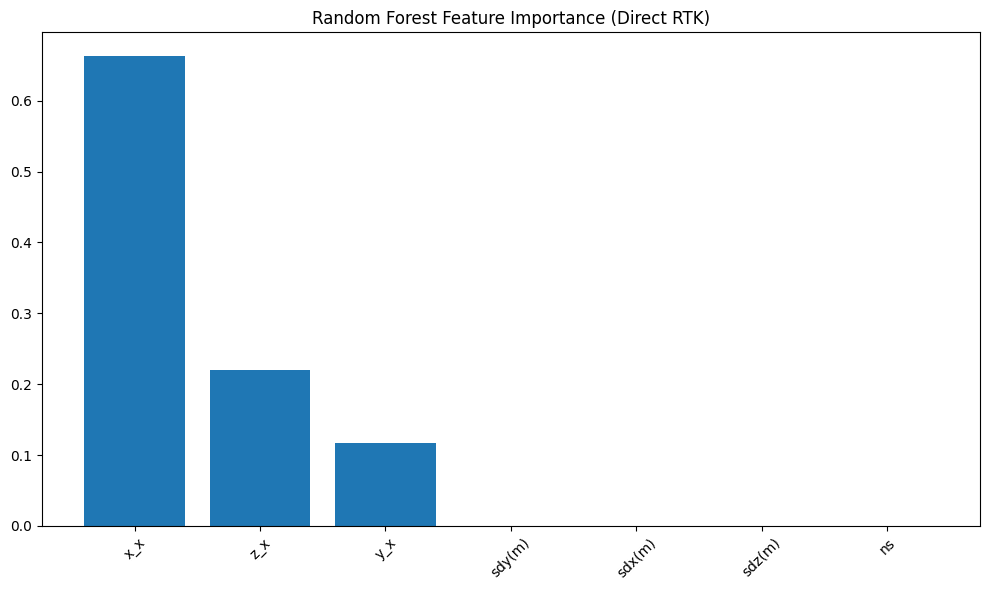


DIRECT MODEL ACCURACY IMPROVEMENT
3D RMSE (SPP):       12.4667 m
3D RMSE (Predicted): 3.5564 m

Improvement: 8.9104 m (71.47%)

Final Accuracy Comparison Table (RMSE in meters):

        SPP  RTK  Direct_Prediction
X    1.7253    0             1.5940
Y    9.6843    0             2.6577
Z    7.6589    0             1.7446
3D  12.4667    0             3.5564

✓ Direct RTK model saved successfully!


In [51]:
model, x_scaler, y_scaler, X_test, y_pred = train_direct_rtk_model(
    unified_df,
    feature_cols
)

test_df = unified_df.loc[X_test.index]

calculate_direct_model_improvement(
    test_df,
    y_pred,
    (spp_x, spp_y, spp_z)
)

generate_direct_model_table(
    test_df,
    y_pred,
    (spp_x, spp_y, spp_z)
)

joblib.dump(model, 'direct_rtk_model.joblib')
joblib.dump(x_scaler, 'x_scaler_direct.joblib')
joblib.dump(y_scaler, 'y_scaler_direct.joblib')
joblib.dump(feature_cols, 'feature_cols_direct.joblib')

print("\n✓ Direct RTK model saved successfully!")



## **Scenario 3**

In [52]:
'''
Model_X → predicts x_y
Model_Y → predicts y_y
Model_Z → predicts z_y
'''


'\nModel_X → predicts x_y\nModel_Y → predicts y_y\nModel_Z → predicts z_y\n'

In [54]:
def train_separate_axis_models(unified_df, feature_cols):

    print("\n" + "="*80)
    print("SCENARIO 3: DIRECT RTK – SEPARATE MODEL PER AXIS")
    print("="*80)

    # -----------------------------
    # Features
    # -----------------------------
    X = unified_df[feature_cols]

    # -----------------------------
    # Targets (RTK)
    # -----------------------------
    y_x = unified_df['x_y']
    y_y = unified_df['y_y']
    y_z = unified_df['z_y']

    # -----------------------------
    # Single train/test split (important!)
    # -----------------------------
    X_train, X_test, yx_train, yx_test, yy_train, yy_test, yz_train, yz_test = \
        train_test_split(
            X, y_x, y_y, y_z,
            test_size=0.2,
            random_state=42
        )

    # -----------------------------
    # Scaling
    # -----------------------------
    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)

    # -----------------------------
    # Model builder (same parameters)
    # -----------------------------
    def build_model():
        return RandomForestRegressor(
            n_estimators=300,
            max_depth=20,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )

    model_x = build_model()
    model_y = build_model()
    model_z = build_model()

    # -----------------------------
    # Train each axis independently
    # -----------------------------
    model_x.fit(X_train_scaled, yx_train)
    model_y.fit(X_train_scaled, yy_train)
    model_z.fit(X_train_scaled, yz_train)

    # -----------------------------
    # Prediction
    # -----------------------------
    pred_x = model_x.predict(X_test_scaled)
    pred_y = model_y.predict(X_test_scaled)
    pred_z = model_z.predict(X_test_scaled)

    y_test_vals = np.column_stack((yx_test, yy_test, yz_test))
    y_pred = np.column_stack((pred_x, pred_y, pred_z))

    # -----------------------------
    # Evaluation
    # -----------------------------
    errors = y_test_vals - y_pred

    rmse_x = np.sqrt(np.mean(errors[:, 0]**2))
    rmse_y = np.sqrt(np.mean(errors[:, 1]**2))
    rmse_z = np.sqrt(np.mean(errors[:, 2]**2))

    error_3d = np.sqrt(errors[:, 0]**2 +
                       errors[:, 1]**2 +
                       errors[:, 2]**2)

    rmse_3d = np.sqrt(np.mean(error_3d**2))

    print("\nRESULTS")
    print(f"X → R²: {r2_score(y_test_vals[:,0], pred_x):.4f} | RMSE: {rmse_x:.4f}")
    print(f"Y → R²: {r2_score(y_test_vals[:,1], pred_y):.4f} | RMSE: {rmse_y:.4f}")
    print(f"Z → R²: {r2_score(y_test_vals[:,2], pred_z):.4f} | RMSE: {rmse_z:.4f}")
    print(f"\n3D RMSE: {rmse_3d:.4f} m")

    return (model_x, model_y, model_z,
            x_scaler,
            X_test,
            y_pred)


In [55]:
def calculate_improvement_separate_model(test_df, predicted_rtk, spp_cols):

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # --- Original SPP error ---
    spp_dx = test_df['x_y'] - test_df[spp_x_col]
    spp_dy = test_df['y_y'] - test_df[spp_y_col]
    spp_dz = test_df['z_y'] - test_df[spp_z_col]

    original_3d = np.sqrt(spp_dx**2 + spp_dy**2 + spp_dz**2)
    rmse_original = np.sqrt(np.mean(original_3d**2))

    # --- Predicted error ---
    pred_dx = test_df['x_y'].values - predicted_rtk[:, 0]
    pred_dy = test_df['y_y'].values - predicted_rtk[:, 1]
    pred_dz = test_df['z_y'].values - predicted_rtk[:, 2]

    predicted_3d = np.sqrt(pred_dx**2 + pred_dy**2 + pred_dz**2)
    rmse_predicted = np.sqrt(np.mean(predicted_3d**2))

    improvement = rmse_original - rmse_predicted
    improvement_percent = (improvement / rmse_original) * 100

    print("\n" + "="*80)
    print("IMPROVEMENT ANALYSIS (SEPARATE MODELS)")
    print("="*80)
    print(f"3D RMSE (SPP):       {rmse_original:.4f} m")
    print(f"3D RMSE (Predicted): {rmse_predicted:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

    return rmse_original, rmse_predicted


In [56]:
def generate_table_separate_model(test_df, predicted_rtk, spp_cols):

    spp_x_col, spp_y_col, spp_z_col = spp_cols

    def rmse(arr):
        return np.sqrt(np.mean(arr**2))

    # SPP residuals
    spp_x = test_df['x_y'] - test_df[spp_x_col]
    spp_y = test_df['y_y'] - test_df[spp_y_col]
    spp_z = test_df['z_y'] - test_df[spp_z_col]

    # Model residuals
    pred_x = test_df['x_y'].values - predicted_rtk[:, 0]
    pred_y = test_df['y_y'].values - predicted_rtk[:, 1]
    pred_z = test_df['z_y'].values - predicted_rtk[:, 2]

    spp_3d = rmse(np.sqrt(spp_x**2 + spp_y**2 + spp_z**2))
    pred_3d = rmse(np.sqrt(pred_x**2 + pred_y**2 + pred_z**2))

    table = pd.DataFrame({
        "SPP": [
            rmse(spp_x),
            rmse(spp_y),
            rmse(spp_z),
            spp_3d
        ],
        "RTK": [0, 0, 0, 0],
        "Separate_Model": [
            rmse(pred_x),
            rmse(pred_y),
            rmse(pred_z),
            pred_3d
        ]
    }, index=["X", "Y", "Z", "3D"])

    print("\nFinal Accuracy Comparison Table (RMSE in meters):\n")
    print(table.round(4))

    return table


## **Scenario 3 Evaluation Table**

In [57]:
model_x, model_y, model_z, x_scaler, X_test, y_pred = \
    train_separate_axis_models(unified_df, feature_cols)

test_df = unified_df.loc[X_test.index]

calculate_improvement_separate_model(
    test_df,
    y_pred,
    (spp_x, spp_y, spp_z)
)

generate_table_separate_model(
    test_df,
    y_pred,
    (spp_x, spp_y, spp_z)
)


joblib.dump(model_x, 'model_x.joblib')
joblib.dump(model_y, 'model_y.joblib')
joblib.dump(model_z, 'model_z.joblib')
joblib.dump(x_scaler, 'x_scaler_separate.joblib')
joblib.dump(feature_cols, 'feature_cols_separate.joblib')

print("\n✓ Separate axis models saved successfully!")



SCENARIO 3: DIRECT RTK – SEPARATE MODEL PER AXIS

RESULTS
X → R²: 1.0000 | RMSE: 1.3247
Y → R²: 0.9996 | RMSE: 2.4760
Z → R²: 0.9999 | RMSE: 1.7371

3D RMSE: 3.3019 m

IMPROVEMENT ANALYSIS (SEPARATE MODELS)
3D RMSE (SPP):       12.4667 m
3D RMSE (Predicted): 3.3019 m

Improvement: 9.1648 m (73.51%)

Final Accuracy Comparison Table (RMSE in meters):

        SPP  RTK  Separate_Model
X    1.7253    0          1.3247
Y    9.6843    0          2.4760
Z    7.6589    0          1.7371
3D  12.4667    0          3.3019

✓ Separate axis models saved successfully!


## Logic of compared scenarios

In [58]:
'''
# =============================================================================
# GNSS POSITIONING IMPROVEMENT – MODELING SCENARIOS
# =============================================================================
#
# This project evaluates three different machine learning approaches
# for improving GNSS SPP positioning accuracy using Random Forest.
#
# Common Model Parameters (used in ALL scenarios):
# -------------------------------------------------
# RandomForestRegressor(
#     n_estimators=300,
#     max_depth=20,
#     min_samples_leaf=2,
#     random_state=42,
#     n_jobs=-1
# )
#
# Data Split:
# -----------
# train_test_split(test_size=0.2, random_state=42)
#
# Evaluation Metrics:
# -------------------
# - RMSE per axis (X, Y, Z)
# - 3D RMSE = sqrt(mean((sqrt(dx² + dy² + dz²))²))
# - R² score per axis
#
# =============================================================================
# SCENARIO 1 — RESIDUAL LEARNING (Predict Correction)
# =============================================================================
#
# Objective:
#   Predict the difference between RTK and SPP:
#
#       diff_x = RTK_x - SPP_x
#       diff_y = RTK_y - SPP_y
#       diff_z = RTK_z - SPP_z
#
# Model learns:
#       GNSS Features → Correction Offset (diff_x, diff_y, diff_z)
#
# After prediction:
#       Corrected_Position = SPP + Predicted_Diff
#
# Evaluation:
#       Error = RTK - Corrected_Position
#       Compute RMSE_X, RMSE_Y, RMSE_Z, 3D_RMSE
#
# Why this works:
#   - Model learns small values (meters)
#   - Easier regression problem
#   - Typically most stable and accurate
#
# =============================================================================
# SCENARIO 2 — DIRECT RTK PREDICTION (Single Multi-Output Model)
# =============================================================================
#
# Objective:
#   Predict RTK coordinates directly:
#
#       Target = [RTK_x, RTK_y, RTK_z]
#
# Model learns:
#       GNSS Features → Absolute RTK Coordinates
#
# No correction step.
#
# Evaluation:
#       Error = RTK - Predicted_RTK
#       Compute RMSE_X, RMSE_Y, RMSE_Z, 3D_RMSE
#
# Characteristics:
#   - Harder regression problem (large coordinate values)
#   - May be less stable than residual learning
#   - Useful for comparison and scientific completeness
#
# =============================================================================
# SCENARIO 3 — DIRECT RTK (Separate Model Per Axis)
# =============================================================================
#
# Objective:
#   Same as Scenario 2, but train independent models:
#
#       Model_X → predicts RTK_x
#       Model_Y → predicts RTK_y
#       Model_Z → predicts RTK_z
#
# Each model uses:
#       n_estimators=300
#       max_depth=20
#       min_samples_leaf=2
#       random_state=42
#
# Logic:
#   1. Split data once (same train/test indices for all axes)
#   2. Train 3 independent RandomForest models
#   3. Combine predictions
#   4. Evaluate per-axis RMSE and 3D RMSE
#
# Why this may help:
#   - Axes behave differently (horizontal vs vertical)
#   - Allows specialization per axis
#   - Can slightly improve vertical or Y performance
#
# =============================================================================
# EXPERIMENTAL COMPARISON FRAMEWORK
# =============================================================================
#
# Baseline:
#   Raw SPP vs RTK (compute RMSE)
#
# Compare:
#   1. Residual Model (Scenario 1)
#   2. Direct RTK Model (Scenario 2)
#   3. Separate Axis Models (Scenario 3)
#
# Final evaluation table should include:
#   - RMSE_X
#   - RMSE_Y
#   - RMSE_Z
#   - 3D_RMSE
#   - Improvement (%) vs SPP
#
# =============================================================================
# Insight:
# =============================================================================
# - Scenario 1 (Residual) often performs best.
# - Scenario 3 may slightly improve certain axes.
# - Scenario 2 is hardest due to large coordinate prediction.
'''

'\n# =============================================================================\n# GNSS POSITIONING IMPROVEMENT – MODELING SCENARIOS\n# =============================================================================\n#\n# This project evaluates three different machine learning approaches\n# for improving GNSS SPP positioning accuracy using Random Forest.\n#\n# Common Model Parameters (used in ALL scenarios):\n# -------------------------------------------------\n# RandomForestRegressor(\n#     n_estimators=300,\n#     max_depth=20,\n#     min_samples_leaf=2,\n#     random_state=42,\n#     n_jobs=-1\n# )\n#\n# Data Split:\n# -----------\n# train_test_split(test_size=0.2, random_state=42)\n#\n# Evaluation Metrics:\n# -------------------\n# - RMSE per axis (X, Y, Z)\n# - 3D RMSE = sqrt(mean((sqrt(dx² + dy² + dz²))²))\n# - R² score per axis\n#\n# =============================================================================\n# SCENARIO 1 — RESIDUAL LEARNING (Predict Correction)\n# =========

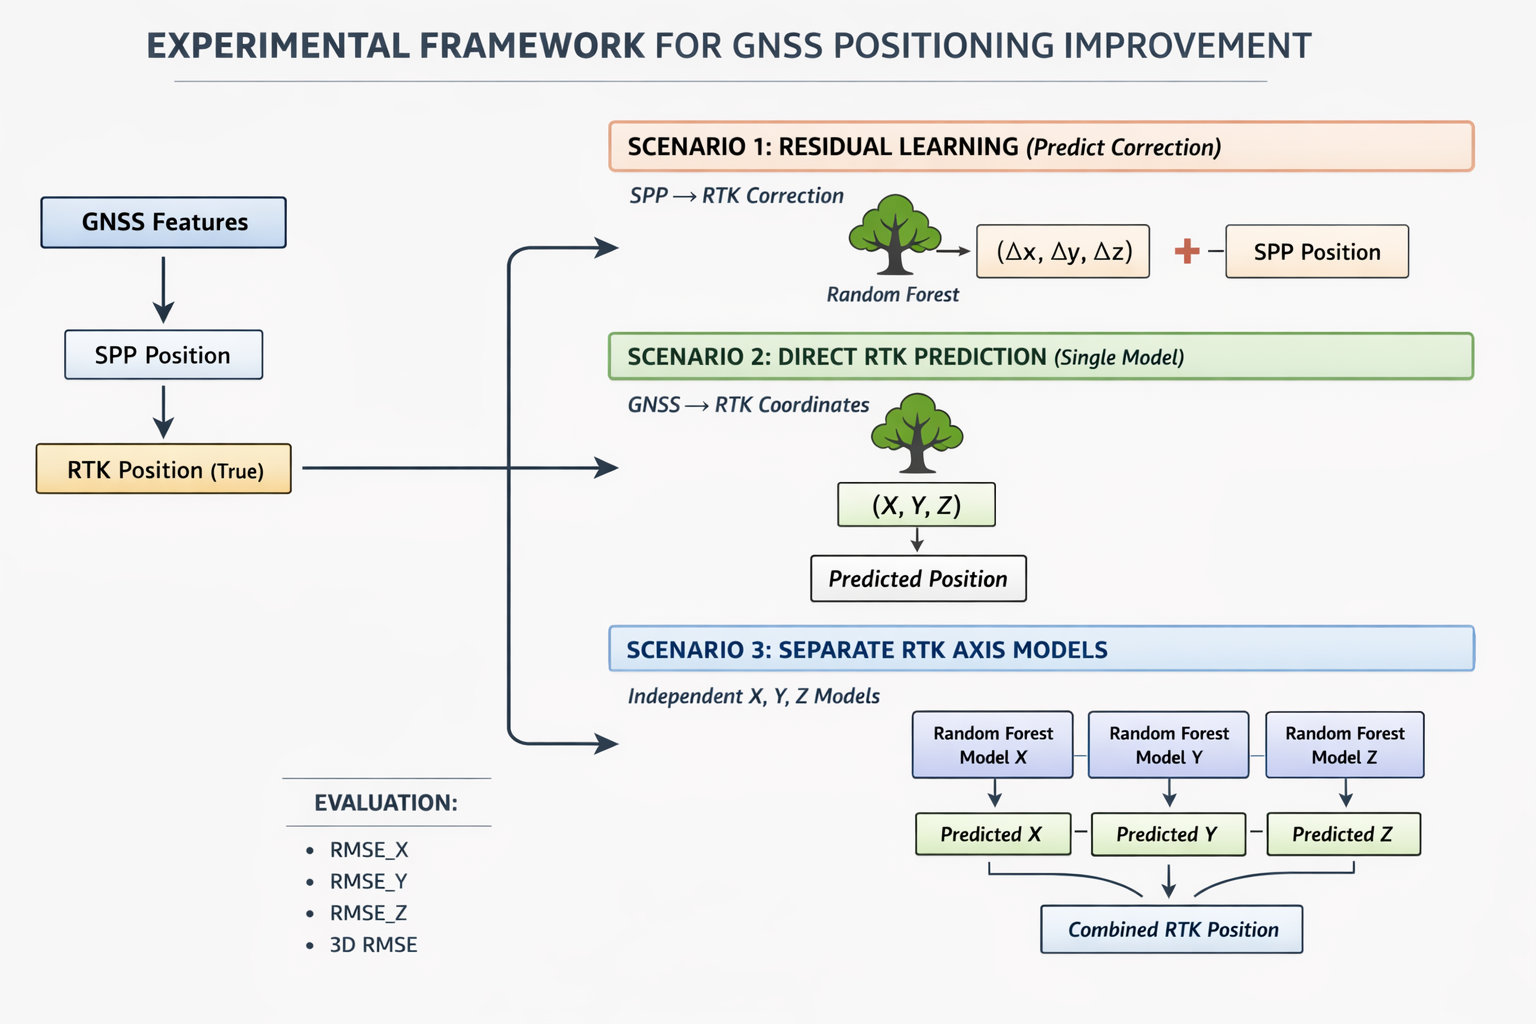

In [61]:
Scenarios_Approached = '/content/Scenarios Approached.png'
from IPython.display import Image, display

display(Image(Scenarios_Approached))